# Titanic Data Story and Predictive Analytics EDA

This notebook follows the one-pass workflow: it loads the Titanic dataset once, saves the raw fallback in the same folder, applies defensible missing-value handling, tells the data story with charts and written interpretation, and then performs the EDA checks that support the later modeling notebook.


In [65]:
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

raw_path = Path('analytics/titanic.csv')
raw_path.parent.mkdir(exist_ok=True)

# Load the dataset exactly once from Seaborn's online cache and save an offline fallback.
df = sns.load_dataset('titanic')
df.to_csv(raw_path, index=False)

print('Raw shape:', df.shape)
print('\n--- df.info() ---')
df.info()
print('\n--- df.describe() ---')
print(df.describe(include='all').T)
print('\n--- missing percentages ---')
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct)


Raw shape: (891, 15)

--- df.info() ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

--- df.describe() ---
             count unique      

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [55]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [57]:
# Missing-value handling by column using the threshold rule.
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
print('Missing percentages before cleaning:')
print(missing_pct[missing_pct > 0].round(2))

# deck: 77.22% missing -> drop column (too unreliable to impute)
# age: 19.87% missing -> impute median because 5% to 30%
# embarked / embark_town: 0.22% missing -> drop rows (under 5%)
clean = df.copy()
clean = clean.drop(columns=['deck'])
clean = clean.dropna(subset=['embarked', 'embark_town'])
clean['age'] = clean['age'].fillna(clean['age'].median())

print('\nAfter cleaning shape:', clean.shape)
print('\nMissing values after cleaning:')
print(clean.isna().sum())


Missing percentages before cleaning:
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

After cleaning shape: (889, 14)

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


--- AGE ---
Q1=22.0000, Q3=35.0000, IQR=13.0000, lower=2.5000, upper=54.5000
Outlier count = 65
Mean = 29.3152, Median = 28.0000, Mode = 28.0000
--- FARE ---
Q1=7.8958, Q3=31.0000, IQR=23.1042, lower=-26.7605, upper=65.6563
Outlier count = 114
Mean = 32.0967, Median = 14.4542, Mode = 8.0500


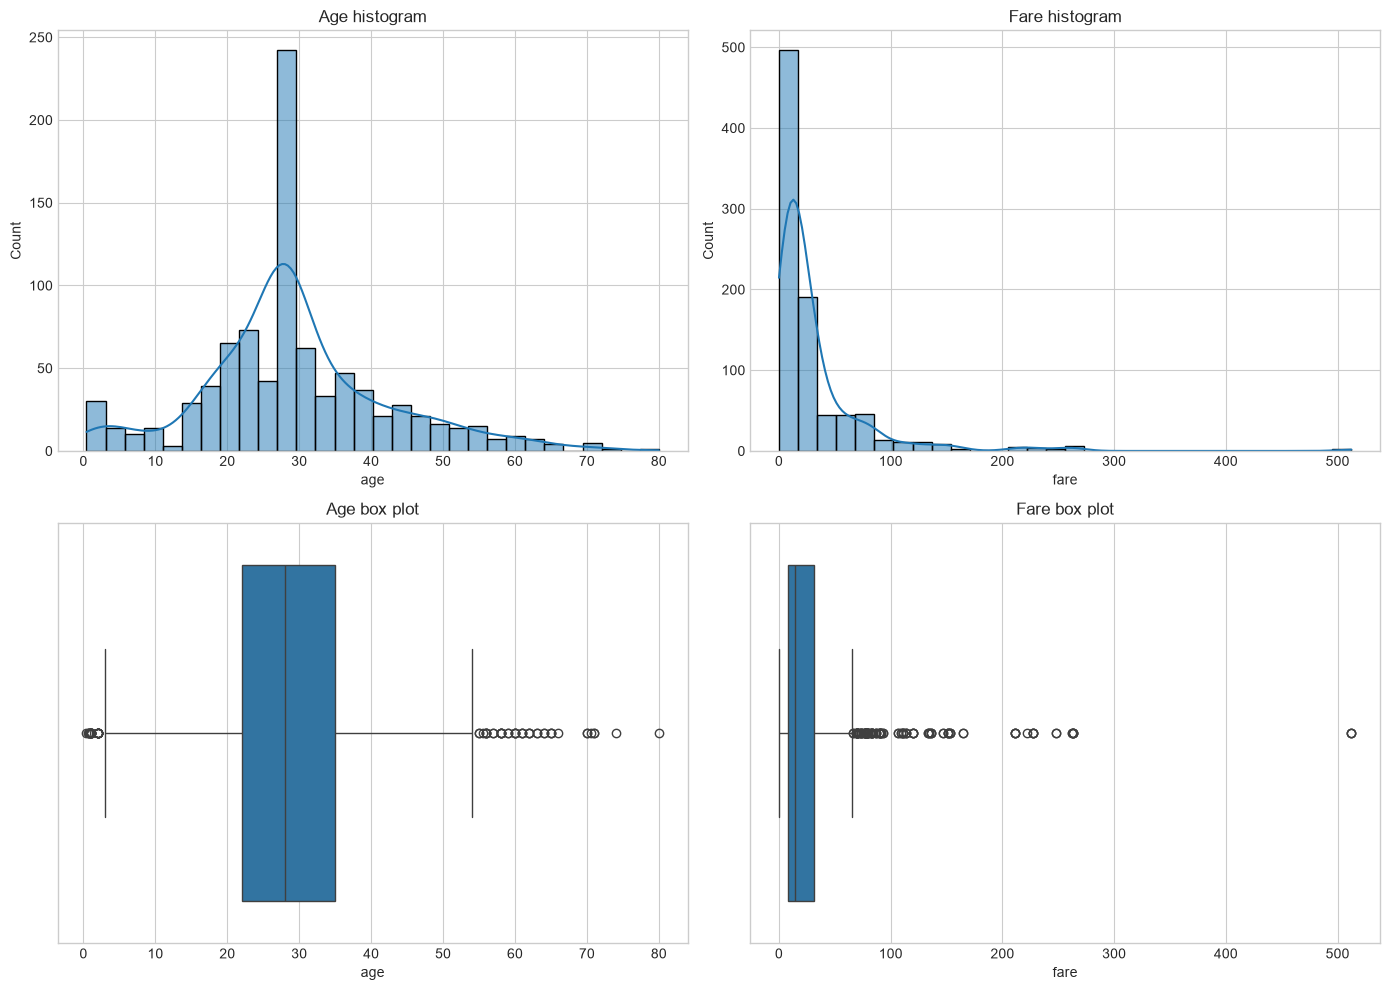

Fare mean=32.0967, median=14.4542, mode=8.0500
Fare distribution is right-skewed because mean > median > mode.


In [58]:
# Univariate analysis for age and fare
for col in ['age', 'fare']:
    q1 = clean[col].quantile(0.25)
    q3 = clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = clean[(clean[col] < lower) | (clean[col] > upper)]
    print(f'--- {col.upper()} ---')
    print(f'Q1={q1:.4f}, Q3={q3:.4f}, IQR={iqr:.4f}, lower={lower:.4f}, upper={upper:.4f}')
    print(f'Outlier count = {len(outliers)}')
    print(f'Mean = {clean[col].mean():.4f}, Median = {clean[col].median():.4f}, Mode = {clean[col].mode().iloc[0]:.4f}')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten()[:2], ['age', 'fare']):
    sns.histplot(clean[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col.title()} histogram')

for ax, col in zip(axes.flatten()[2:], ['age', 'fare']):
    sns.boxplot(x=clean[col], ax=ax)
    ax.set_title(f'{col.title()} box plot')

plt.tight_layout()
plt.show()

fare = clean['fare']
print(f'Fare mean={fare.mean():.4f}, median={fare.median():.4f}, mode={fare.mode().iloc[0]:.4f}')
print('Fare distribution is right-skewed because mean > median > mode.')


Survival rate by sex:
sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.626168
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival rate by sex and pclass:
pclass         1         2         3
sex                                 
female  0.967391  0.921053  0.500000
male    0.368852  0.157407  0.135447

Correlation matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000

Top absolute off-diagonal correlations:
('pclass', 'fare', np.float64(-0.548193285236645))
('sibsp', 'parch', np

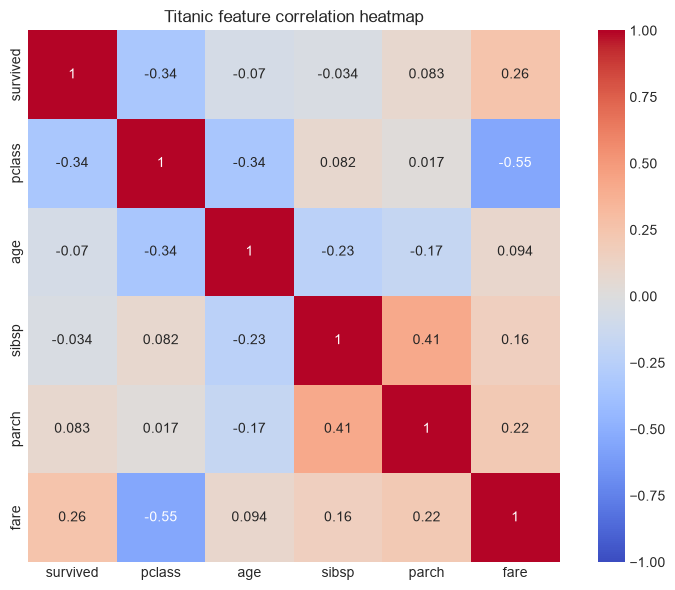

In [59]:
# Bivariate analysis: survival rates by sex, class, and sex/class cross-tab
sex_survival = clean.groupby('sex')['survived'].mean()
pclass_survival = clean.groupby('pclass')['survived'].mean()
sex_pclass_survival = clean.groupby(['sex', 'pclass'])['survived'].mean().unstack()

print('Survival rate by sex:')
print(sex_survival)
print('\nSurvival rate by pclass:')
print(pclass_survival)
print('\nSurvival rate by sex and pclass:')
print(sex_pclass_survival)

# Correlation matrix restricted to the six required columns only.
correlation_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
correlation_matrix = clean[correlation_cols].corr()
print('\nCorrelation matrix:')
print(correlation_matrix)

# Rank all off-diagonal pairs by largest absolute correlation.
off_diag_pairs = []
for i in range(len(correlation_cols)):
    for j in range(i + 1, len(correlation_cols)):
        a = correlation_cols[i]
        b = correlation_cols[j]
        off_diag_pairs.append((a, b, correlation_matrix.loc[a, b]))

ranked_pairs = sorted(off_diag_pairs, key=lambda x: abs(x[2]), reverse=True)
print('\nTop absolute off-diagonal correlations:')
for pair in ranked_pairs[:5]:
    print(pair)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Titanic feature correlation heatmap')
plt.tight_layout()
plt.show()


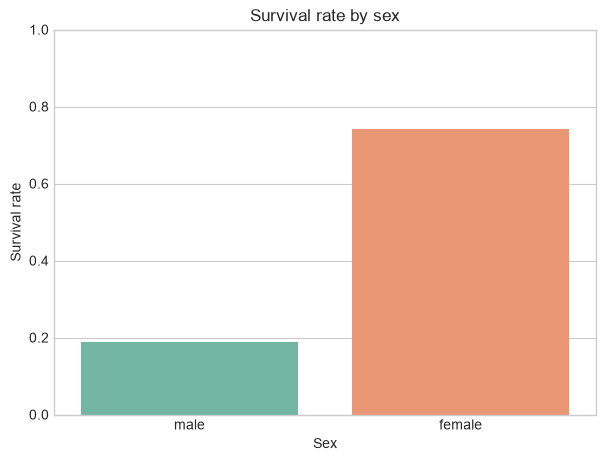

Interpretation: Women had a substantially higher survival rate than men. This indicates a strong sex-based survival split, likely reflecting both social priorities during evacuation and the passenger mix across ticket classes.


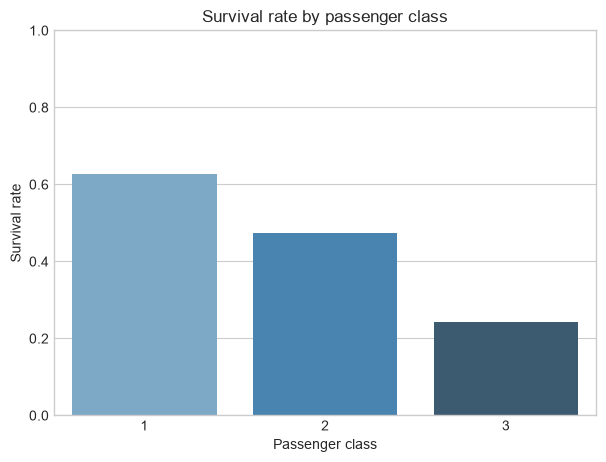

Interpretation: First-class passengers had the highest survival probability, followed by second class and then third class. This supports the idea that passenger class captured both social privilege and access to safer positions during the disaster.


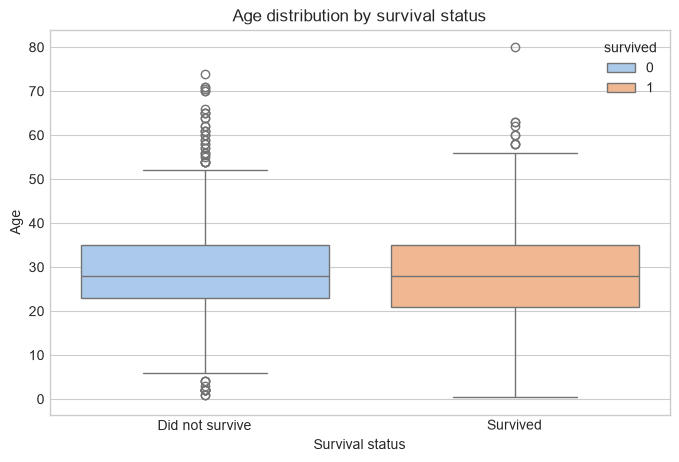

Interpretation: Children and younger adults appear more likely to survive than older passengers. The reduced median age among survivors is consistent with a prioritization of younger and more physically robust passengers during evacuation.


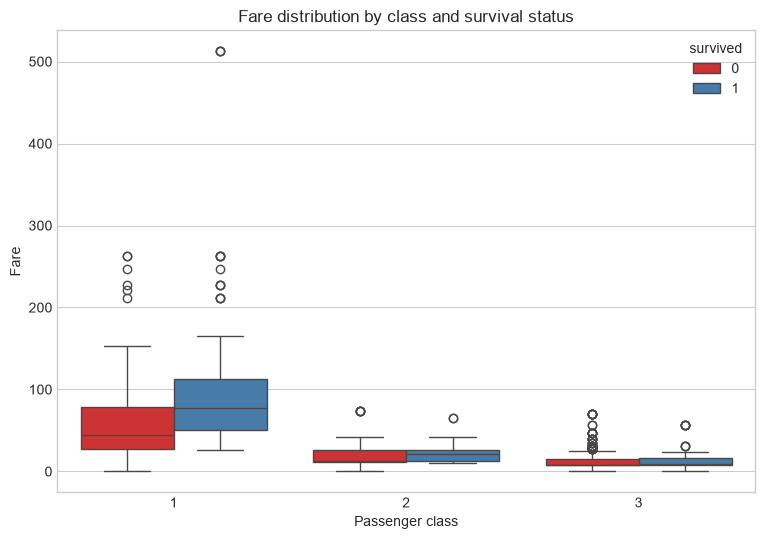

Interpretation: Higher fares clustered in first class, and those passengers also had much higher survival odds. This reinforces that fare, class, and social privilege are tightly linked and together tell a strong story about survival disadvantage for lower-class passengers.


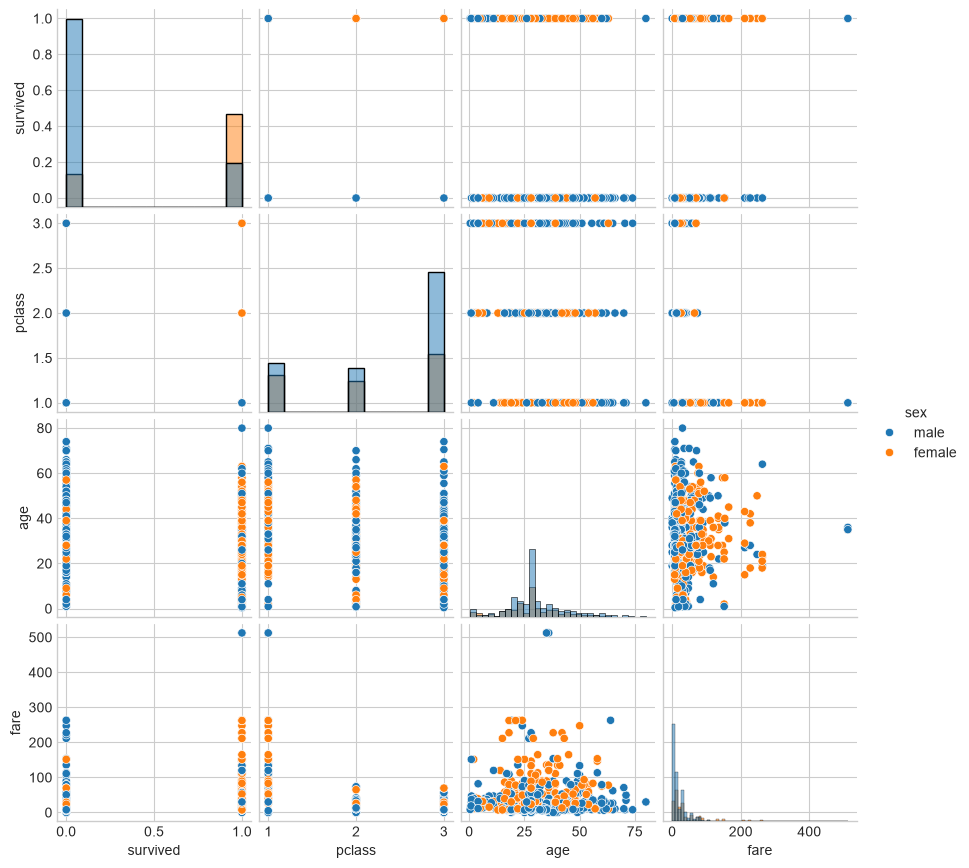

Interpretation: The pairwise views show that women and higher-class passengers occupy the regions associated with better survival outcomes. Together, the plots portray a consistent narrative in which social position and sex strongly shaped risk exposure and rescue access.


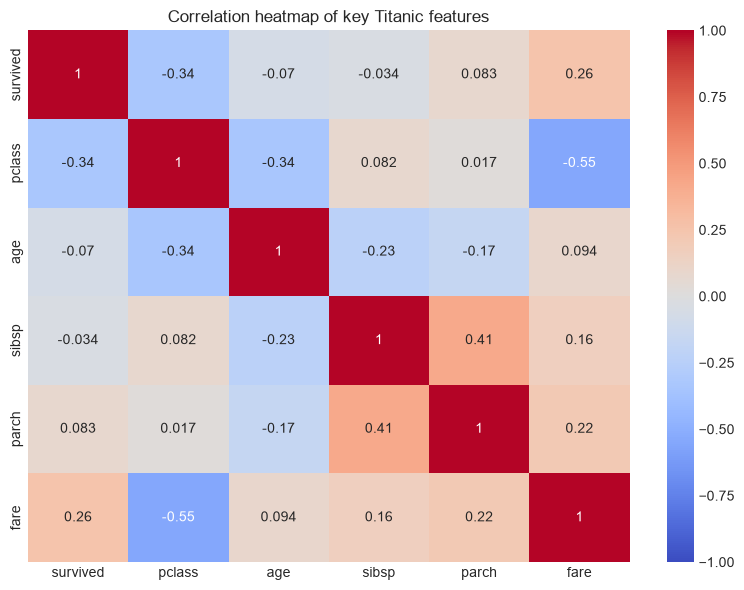

Interpretation: The strongest correlations are pclass-fare and sibsp-parch, while survival is most positively related to fare and negatively related to pclass. This indicates that socioeconomic status and family structure mattered more than simple age alone in explaining survival patterns.

Before standardization:
            age       fare
mean  29.315152  32.096681
std   12.984932  49.697504

After standardization:
             age_z        fare_z
mean  2.717486e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


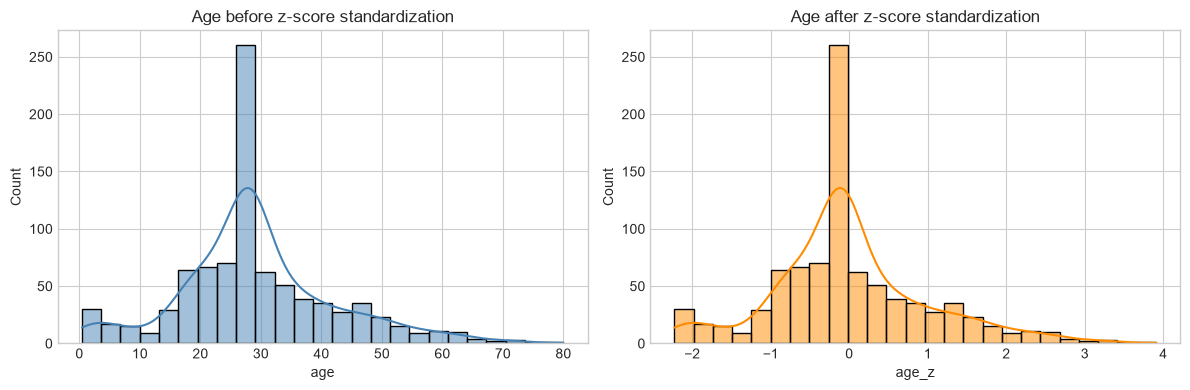

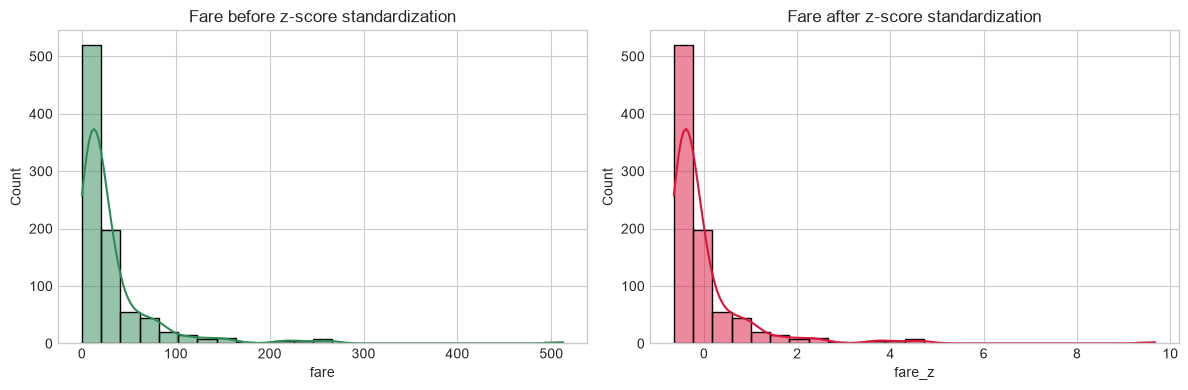

The transformed age and fare columns have approximately mean 0 and standard deviation 1, confirming the standardization check.

Saved cleaned data to analytics/titanic_cleaned.csv


In [60]:
# Multivariate data story: at least 4 distinct views

# Chart 1: survival by sex
plt.figure(figsize=(7, 5))
sns.barplot(data=clean, x='sex', y='survived', estimator='mean', errorbar=None, palette='Set2')
plt.title('Survival rate by sex')
plt.ylabel('Survival rate')
plt.xlabel('Sex')
plt.ylim(0, 1)
plt.show()
print('Interpretation: Women had a substantially higher survival rate than men. This indicates a strong sex-based survival split, likely reflecting both social priorities during evacuation and the passenger mix across ticket classes.')

# Chart 2: survival by passenger class
plt.figure(figsize=(7, 5))
sns.barplot(data=clean, x='pclass', y='survived', estimator='mean', errorbar=None, palette='Blues_d')
plt.title('Survival rate by passenger class')
plt.ylabel('Survival rate')
plt.xlabel('Passenger class')
plt.ylim(0, 1)
plt.show()
print('Interpretation: First-class passengers had the highest survival probability, followed by second class and then third class. This supports the idea that passenger class captured both social privilege and access to safer positions during the disaster.')

# Chart 3: age distribution by survival status
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean, x='survived', y='age', hue='survived', dodge=False, palette='pastel')
plt.title('Age distribution by survival status')
plt.xticks([0, 1], ['Did not survive', 'Survived'])
plt.ylabel('Age')
plt.xlabel('Survival status')
plt.show()
print('Interpretation: Children and younger adults appear more likely to survive than older passengers. The reduced median age among survivors is consistent with a prioritization of younger and more physically robust passengers during evacuation.')

# Chart 4: fare distribution by class and survival status
plt.figure(figsize=(9, 6))
sns.boxplot(data=clean, x='pclass', y='fare', hue='survived', palette='Set1')
plt.title('Fare distribution by class and survival status')
plt.ylabel('Fare')
plt.xlabel('Passenger class')
plt.show()
print('Interpretation: Higher fares clustered in first class, and those passengers also had much higher survival odds. This reinforces that fare, class, and social privilege are tightly linked and together tell a strong story about survival disadvantage for lower-class passengers.')

# Chart 5: pairplot on key variables
sns.pairplot(clean[['survived', 'pclass', 'age', 'fare', 'sex']], hue='sex', diag_kind='hist', height=2.2)
plt.show()
print('Interpretation: The pairwise views show that women and higher-class passengers occupy the regions associated with better survival outcomes. Together, the plots portray a consistent narrative in which social position and sex strongly shaped risk exposure and rescue access.')

# Chart 6: correlation heatmap of key feature relationships
plt.figure(figsize=(8, 6))
key_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
sns.heatmap(clean[key_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap of key Titanic features')
plt.tight_layout()
plt.show()
print('Interpretation: The strongest correlations are pclass-fare and sibsp-parch, while survival is most positively related to fare and negatively related to pclass. This indicates that socioeconomic status and family structure mattered more than simple age alone in explaining survival patterns.')

# Standardization sanity check: z = (x - mean) / std on the full cleaned DataFrame.
age_mean = clean['age'].mean()
age_std = clean['age'].std(ddof=0)
fare_mean = clean['fare'].mean()
fare_std = clean['fare'].std(ddof=0)

clean['age_z'] = (clean['age'] - age_mean) / age_std
clean['fare_z'] = (clean['fare'] - fare_mean) / fare_std

print('\nBefore standardization:')
print(clean[['age', 'fare']].describe().loc[['mean', 'std']])
print('\nAfter standardization:')
print(clean[['age_z', 'fare_z']].describe().loc[['mean', 'std']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean['age'], bins=25, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age before z-score standardization')

sns.histplot(clean['age_z'], bins=25, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Age after z-score standardization')
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(clean['fare'], bins=25, kde=True, ax=axes[0], color='seagreen')
axes[0].set_title('Fare before z-score standardization')

sns.histplot(clean['fare_z'], bins=25, kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Fare after z-score standardization')
plt.tight_layout(); plt.show()

print('The transformed age and fare columns have approximately mean 0 and standard deviation 1, confirming the standardization check.')

# Save the cleaned dataset for downstream modeling.
clean.to_csv('analytics/titanic_cleaned.csv', index=False)
print('\nSaved cleaned data to analytics/titanic_cleaned.csv')
